In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# ================================
# LOAD MONTHLY TRADING DATASET
# ================================

sp500_path = "../../data/macro_processed/sp500_processed.csv"
tbill_path = "../../data/macro_processed/3m_yield_processed.csv"

# --- Load S&P500 level ---
sp500_raw = pd.read_csv(sp500_path, parse_dates=["date"]).set_index("date")
sp500 = sp500_raw[["value"]].rename(columns={"value": "SP500"})

# --- Load 3M T-bill (annualized %) ---
tbill_raw = pd.read_csv(tbill_path, parse_dates=["date"]).set_index("date")
tbill = tbill_raw[["value"]].rename(columns={"value": "TB3MS"})

# ================================
# Build monthly *log* returns
# ================================

# S&P 500 monthly log returns
sp500_m = sp500.resample("ME").last()
sp500_ret = np.log(sp500_m["SP500"] / sp500_m["SP500"].shift(1)).dropna()
sp500_ret.index = sp500_ret.index.to_period("M")

# 3M T-bill monthly log return from annual yield
tbill_m = tbill.resample("ME").last()
rf_ann = tbill_m["TB3MS"] / 100.0
rf_ret = np.log((1 + rf_ann) ** (1/12)).dropna()
rf_ret.index = rf_ret.index.to_period("M")

# Align
idx = sp500_ret.index.intersection(rf_ret.index)
sp500_ret = sp500_ret.loc[idx]
rf_ret = rf_ret.loc[idx]

# Build data frame
data = pd.DataFrame({
    "sp500_ret": sp500_ret,
    "rf_ret": rf_ret
})
data["erp"] = data["sp500_ret"] - data["rf_ret"]

print("Monthly dataset:", data.shape)
display(data.head())

Monthly dataset: (431, 3)


,sp500_ret,rf_ret,erp
date,,,
1990-01,-0.071300,0.006413,-0.077713
1990-02,0.008503,0.006444,0.002058
1990-03,0.023966,0.006467,0.017498
1990-04,-0.027255,0.006467,-0.033723
1990-05,0.088001,0.006421,0.081580


In [2]:
# ====================================
# TARGET: Next-month ERP (erp_next)
# ====================================

data["erp_next"] = data["erp"].shift(-1)

model_df = data.dropna().copy()

print("Modeling base (returns only):", model_df.shape)
display(model_df.head())

Modeling base (returns only): (430, 4)


,sp500_ret,rf_ret,erp,erp_next
date,,,,
1990-01,-0.071300,0.006413,-0.077713,0.002058
1990-02,0.008503,0.006444,0.002058,0.017498
1990-03,0.023966,0.006467,0.017498,-0.033723
1990-04,-0.027255,0.006467,-0.033723,0.081580
1990-05,0.088001,0.006421,0.081580,-0.015339


In [3]:
# ====================================
# LOAD MONTHLY MACRO SERIES
# ====================================

BASE = "../../data/macro_processed_full"   # adjust if needed

def load_monthly_series(path, name):
    """
    Load a macro series, resample to month-end, keep 'value' column.
    Works for monthly or lower-frequency (e.g. quarterly) series.
    Quarterly etc are forward-filled so that we always have a value each month.
    """
    df = (
        pd.read_csv(path, parse_dates=["date"])
        .set_index("date")
        .sort_index()
    )
    df = df[["value"]].rename(columns={"value": name}).resample("ME").last()
    df = df.ffill()   # important: quarterly → monthly via ffill
    return df

paths = {
    # Inflation indices
    "cpi":          f"{BASE}/inflation/cpi_processed.csv",
    "pce":          f"{BASE}/inflation/PCE_price_index_processed.csv",
    "ppi":          f"{BASE}/inflation/PPI_inflation_processed.csv",

    # Growth indicators
    "indprod":      f"{BASE}/ec_growth/industrial_production_processed.csv",
    "retail_sales": f"{BASE}/ec_growth/retail_sales_processed.csv",
    "inventories":  f"{BASE}/ec_growth/tot_business_inventories_processed.csv",
    "export_px":    f"{BASE}/ec_growth/export_price_index_processed.csv",
    "import_px":    f"{BASE}/ec_growth/import_price_index_processed.csv",
    "unemp":        f"{BASE}/ec_growth/unemployment_processed.csv",

    # Money and policy
    "m2":           f"{BASE}/mon_policy/m2_real_money_supply_processed.csv",
    "fedfunds":     f"{BASE}/mon_policy/fedfunds_processed.csv",
    "discount_rate":f"{BASE}/mon_policy/fed_reserve_discount_rate_processed.csv",

    # Yields and spreads
    "spread_10y_2y":f"{BASE}/mkt_vol/10y_2y_spread_processed.csv",
    "nat_fin_cond": f"{BASE}/mkt_vol/nat_fin_condition_indx_processed.csv",
    "nasdaq_vol":   f"{BASE}/mkt_vol/nasdaq_vol_indx_processed.csv",
    "hy_spread":    f"{BASE}/other/bofa_highyield_spread_processed.csv",
    "y2":           f"{BASE}/other/2y_yield_processed.csv",
    "y10":          f"{BASE}/other/10y_yield_processed.csv",
}

macro_list = []
for name, path in paths.items():
    macro_list.append(load_monthly_series(path, name))

macro_m = pd.concat(macro_list, axis=1)
macro_m.index = macro_m.index.to_period("M")

print("Macro monthly shape:", macro_m.shape)
display(macro_m.head())

Macro monthly shape: (1355, 18)


,cpi,pce,ppi,indprod,retail_sales,inventories,export_px,import_px,unemp,m2,fedfunds,discount_rate,spread_10y_2y,nat_fin_cond,nasdaq_vol,hy_spread,y2,y10
date,,,,,,,,,,,,,,,,,,
1913-01,NaN,NaN,12.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1913-02,NaN,NaN,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1913-03,NaN,NaN,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1913-04,NaN,NaN,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1913-05,NaN,NaN,11.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ====================================
# ALIGN MACRO DATA WITH RETURNS
# ====================================

# At month t, we assume we only know macro up to t-1.
# We want to predict ERP_{t+1}.
# So we use macro_{t-1} and current returns (erp_t) to predict erp_{t+1}.

macro_lag = macro_m.shift(1)   # macro at t-1

df = model_df.join(macro_lag, how="inner").dropna()

print("Final modeling dataframe:", df.shape)
display(df.head())

Final modeling dataframe: (247, 22)


,sp500_ret,rf_ret,erp,erp_next,cpi,pce,ppi,indprod,retail_sales,inventories,...,unemp,m2,fedfunds,discount_rate,spread_10y_2y,nat_fin_cond,nasdaq_vol,hy_spread,y2,y10
date,,,,,,,,,,,,,,,,,,,,,
2001-03,-0.066359,0.003508,-0.069867,0.070779,176.0,75.048,137.4,91.2851,272627.0,1182045.0,...,4.2,2850.6,5.49,5.00,0.51,-0.28067,63.65,7.70,4.41,4.92
2001-04,0.074007,0.003228,0.070779,0.002106,176.1,75.055,135.9,91.0585,269820.0,1176840.0,...,4.3,2881.8,5.31,4.81,0.75,-0.25602,62.23,8.18,4.18,4.93
2001-05,0.005077,0.002971,0.002106,-0.028342,176.4,75.187,136.4,90.7384,274410.0,1175468.0,...,4.4,2913.3,4.80,4.28,1.05,-0.33623,61.13,8.06,4.30,5.35
2001-06,-0.025354,0.002987,-0.028342,-0.013697,177.3,75.385,136.8,90.2607,275769.0,1172056.0,...,4.3,2897.5,4.21,3.73,1.21,-0.42536,52.53,7.68,4.22,5.43
2001-07,-0.010798,0.002899,-0.013697,-0.069018,177.7,75.518,135.5,89.7811,274474.0,1163409.0,...,4.5,2915.1,3.97,3.47,1.17,-0.46249,40.15,8.16,4.25,5.42


In [6]:
# ====================================
# STATIC FIT (FULL SAMPLE) + LASSO SELECTION
# ====================================

y = df["erp_next"]
X_all = df.drop(columns=["erp_next"])

print("Number of predictors (including returns):", X_all.shape[1])

# ----- Model 1: OLS with all predictors -----
ols_all = LinearRegression()
ols_all.fit(X_all, y)
y_hat_all_insample = ols_all.predict(X_all)

r2_all = r2_score(y, y_hat_all_insample)
rmse_all = np.sqrt(mean_squared_error(y, y_hat_all_insample))

print("\n=== IN-SAMPLE FIT: ALL PREDICTORS ===")
print(f"R^2 (in-sample):  {r2_all:.4f}")
print(f"RMSE (in-sample): {rmse_all:.6f}")

# ----- LASSO to select a subset of predictors -----

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all.values)

alphas = np.logspace(-3, 0, 80)
tol = 1e-6

best_alpha = None
best_coef = None
best_k = None

for a in sorted(alphas, reverse=True):
    lasso = Lasso(alpha=a, max_iter=50000, random_state=0)
    lasso.fit(X_scaled, y.values)
    coefs = lasso.coef_
    k = np.sum(np.abs(coefs) > tol)
    if 6 <= k <= 10:
        best_alpha = a
        best_coef = coefs
        best_k = k
        break

# Fallback: smallest alpha if no 6–10 solution
if best_alpha is None:
    a = alphas.min()
    lasso = Lasso(alpha=a, max_iter=50000, random_state=0)
    lasso.fit(X_scaled, y.values)
    best_alpha = a
    best_coef = lasso.coef_
    best_k = np.sum(np.abs(best_coef) > tol)

selected_vars = [name for name, c in zip(X_all.columns, best_coef) if abs(c) > tol]

print("\n=== LASSO SELECTION (FULL SAMPLE) ===")
print(f"alpha chosen   : {best_alpha:.5f}")
print(f"non-zero coefs : {best_k}")
print("selected vars  :", selected_vars)

# Reduced X using LASSO-selected variables
X_sel = X_all[selected_vars].copy()

# Reduced OLS for static fit
ols_sel = LinearRegression()
ols_sel.fit(X_sel, y)
y_hat_sel_insample = ols_sel.predict(X_sel)

r2_sel = r2_score(y, y_hat_sel_insample)
rmse_sel = np.sqrt(mean_squared_error(y, y_hat_sel_insample))

print("\n=== IN-SAMPLE FIT: LASSO SUBSET ===")
print(f"R^2 (in-sample):  {r2_sel:.4f}")
print(f"RMSE (in-sample): {rmse_sel:.6f}")

Number of predictors (including returns): 21

=== IN-SAMPLE FIT: ALL PREDICTORS ===
R^2 (in-sample):  0.1774
RMSE (in-sample): 0.039136

=== LASSO SELECTION (FULL SAMPLE) ===
alpha chosen   : 0.00155
non-zero coefs : 6
selected vars  : ['indprod', 'import_px', 'unemp', 'discount_rate', 'nat_fin_cond', 'y10']

=== IN-SAMPLE FIT: LASSO SUBSET ===
R^2 (in-sample):  0.0966
RMSE (in-sample): 0.041013


In [7]:
# ====================================
# ROLLING 3-MONTH OOS FORECASTS
# ====================================

window = 3   # 3-month rolling estimation window

def rolling_forecast(y_series, X_frame, window):
    """
    Rolling-window 1-step-ahead forecasts.
    At time t (row i), train on the previous `window` observations.
    """
    y_vals = y_series.values
    X_vals = X_frame.values
    idx = y_series.index

    preds = []
    pred_idx = []

    for i in range(window, len(y_series)):
        # training window: i-window ... i-1
        X_train = X_vals[i-window:i]
        y_train = y_vals[i-window:i]

        model = LinearRegression()
        model.fit(X_train, y_train)

        # predict y at time i
        y_pred = model.predict(X_vals[i].reshape(1, -1))[0]
        preds.append(y_pred)
        pred_idx.append(idx[i])

    pred_series = pd.Series(preds, index=pred_idx)
    return pred_series

# --- Forecasts with all predictors and with LASSO subset ---
pred_all = rolling_forecast(y, X_all, window)
pred_sel = rolling_forecast(y, X_sel, window)

print("Pred_all shape:", pred_all.shape)
print("Pred_sel shape:", pred_sel.shape)
display(pred_sel.head())

Pred_all shape: (244,)
Pred_sel shape: (244,)


2001-06   -0.029813
2001-07   -0.034079
2001-08   -0.224525
2001-09   -0.085629
2001-10    0.088891
Freq: M, dtype: float64

In [8]:
# ----- OOS accuracy metrics (against historical mean benchmark) -----

y_oos = y.loc[pred_all.index]  # same index for both

def oos_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    sse = np.sum((y_true - y_pred)**2)
    sst = np.sum((y_true - y_true.mean())**2)
    r2_oos = 1 - sse / sst

    print(f"\n=== OOS METRICS: {label} ===")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")
    print(f"R^2  : {r2_oos:.4f}")
    return rmse, mae, r2_oos

oos_metrics(y_oos, pred_all, "All predictors")
oos_metrics(y_oos, pred_sel, "LASSO subset")

# Benchmark: historical mean of *full* sample y
mean_bench = y.mean()
y_bench_oos = pd.Series(mean_bench, index=y_oos.index)
oos_metrics(y_oos, y_bench_oos, "Historical mean benchmark")


=== OOS METRICS: All predictors ===
RMSE : 1.014461
MAE  : 0.286982
R^2  : -551.6165

=== OOS METRICS: LASSO subset ===
RMSE : 0.217868
MAE  : 0.096323
R^2  : -24.4882

=== OOS METRICS: Historical mean benchmark ===
RMSE : 0.043154
MAE  : 0.031639
R^2  : -0.0000


(0.04315441925645813, 0.03163931211508514, -8.647308354037264e-06)

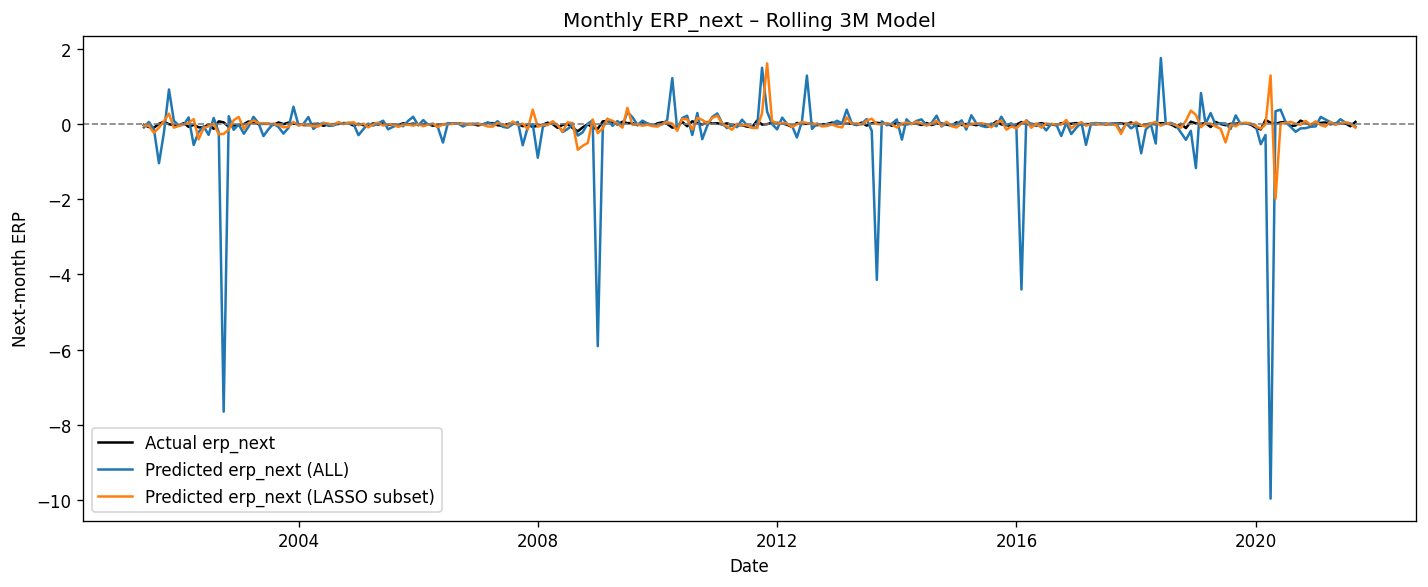

In [20]:
# ====================================
# ACTUAL vs PREDICTED ERP_next (OOS)
# ====================================

idx_oos_ts = y_oos.index.to_timestamp()

plt.figure(figsize=(12,5))
plt.plot(idx_oos_ts, y_oos,       label="Actual erp_next", color="black")
plt.plot(idx_oos_ts, pred_all,    label="Predicted erp_next (ALL)", color="tab:blue")
plt.plot(idx_oos_ts, pred_sel,    label="Predicted erp_next (LASSO subset)", color="tab:orange")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Monthly ERP_next – Rolling 3M Model")
plt.ylabel("Next-month ERP")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ===============================
# BUILD OOS MONTHLY TRADING SET
# ===============================

# Use the common OOS prediction index
valid_idx = pred_all.index.intersection(data.index)

data_oos = data.loc[valid_idx].copy()
pred_all_oos = pred_all.loc[valid_idx].copy()
pred_sel_oos = pred_sel.loc[valid_idx].copy()

print("OOS trading period:", data_oos.index.min(), "→", data_oos.index.max())
display(data_oos.head())

OOS trading period: 2001-06 → 2021-09


,sp500_ret,rf_ret,erp,erp_next
2001-06,-0.025354,0.002987,-0.028342,-0.013697
2001-07,-0.010798,0.002899,-0.013697,-0.069018
2001-08,-0.066256,0.002762,-0.069018,-0.087233
2001-09,-0.085257,0.001976,-0.087233,0.016246
2001-10,0.017937,0.001691,0.016246,0.071014


In [11]:
# ===============================
# STRATEGY WEIGHTING FUNCTIONS
# ===============================

# Strategy A – banded weights using z-score (same bands as ARX(3) version)
def weight_bands(z):
    if z >= 2:   return 1.00   # 100% risky asset
    elif z >= 1: return 0.75
    elif z > -1:return 0.50
    elif z > -2:return 0.25
    else:       return 0.00   # 0% risky asset

# Strategy B – sign rule
def weight_sign(pred):
    return 1.0 if pred > 0 else 0.0

In [12]:
# ===============================
# STRATEGIES A & B – FULL MODEL
# ===============================

sp = data_oos["sp500_ret"]   # log returns
rf = data_oos["rf_ret"]      # log returns

# Z-score of predictions for FULL model (use entire OOS distribution)
mean_full = pred_all_oos.mean()
std_full  = pred_all_oos.std()
z_full    = (pred_all_oos - mean_full) / std_full

# --- Strategy A (bands, full model) ---
wA_stock_full = z_full.apply(weight_bands)
wA_bond_full  = 1 - wA_stock_full

ret_A_full = np.log(wA_stock_full * np.exp(sp) + wA_bond_full * np.exp(rf))

# --- Strategy B (sign, full model) ---
wB_stock_full = pred_all_oos.apply(weight_sign)
wB_bond_full  = 1 - wB_stock_full

ret_B_full = np.log(wB_stock_full * np.exp(sp) + wB_bond_full * np.exp(rf))

# --- Benchmarks for full model ---

# 1. 100% S&P buy & hold (common benchmark)
ret_bench_100 = sp.copy()

# 2. Constant-mix with same average risky weight as Strategy A (full model)
w_bar_full = wA_stock_full.mean()
ret_bench_avg_full = np.log(w_bar_full * np.exp(sp) + (1 - w_bar_full) * np.exp(rf))

print("Average stock weight, Strategy A (full):", w_bar_full)

Average stock weight, Strategy A (full): 0.49385245901639346


In [13]:
# ===============================
# STRATEGIES A & B – LASSO MODEL
# ===============================

# Z-score of predictions for LASSO model
mean_lasso = pred_sel_oos.mean()
std_lasso  = pred_sel_oos.std()
z_lasso    = (pred_sel_oos - mean_lasso) / std_lasso

# --- Strategy A (bands, LASSO) ---
wA_stock_L = z_lasso.apply(weight_bands)
wA_bond_L  = 1 - wA_stock_L

ret_A_L = np.log(wA_stock_L * np.exp(sp) + wA_bond_L * np.exp(rf))

# --- Strategy B (sign, LASSO) ---
wB_stock_L = pred_sel_oos.apply(weight_sign)
wB_bond_L  = 1 - wB_stock_L

ret_B_L = np.log(wB_stock_L * np.exp(sp) + wB_bond_L * np.exp(rf))

# Constant-mix benchmark for LASSO (average risky weight of Strategy A LASSO)
w_bar_L = wA_stock_L.mean()
ret_bench_avg_L = np.log(w_bar_L * np.exp(sp) + (1 - w_bar_L) * np.exp(rf))

print("Average stock weight, Strategy A (LASSO):", w_bar_L)

Average stock weight, Strategy A (LASSO): 0.4959016393442623


In [14]:
# ===============================
# PERFORMANCE STATISTICS
# ===============================

def geom_annual_from_log(r):
    r = r.dropna()
    return np.exp(r.mean() * 12) - 1

def sharpe_annual_from_log(r, rf_series):
    r, rf_series = r.align(rf_series, join="inner")
    ex = r - rf_series
    return np.sqrt(12) * ex.mean() / ex.std()

print("\n=== ANNUALIZED RETURNS (log → geometric) ===")
print(f"Strategy A (full)   : {geom_annual_from_log(ret_A_full):.4f}")
print(f"Strategy B (full)   : {geom_annual_from_log(ret_B_full):.4f}")
print(f"Strategy A (LASSO)  : {geom_annual_from_log(ret_A_L):.4f}")
print(f"Strategy B (LASSO)  : {geom_annual_from_log(ret_B_L):.4f}")
print(f"Benchmark 100% S&P  : {geom_annual_from_log(ret_bench_100):.4f}")
print(f"Benchmark avg (full): {geom_annual_from_log(ret_bench_avg_full):.4f}")
print(f"Benchmark avg (LASSO): {geom_annual_from_log(ret_bench_avg_L):.4f}")

print("\n=== ANNUALIZED SHARPE (vs 3M T-bill) ===")
print(f"Strategy A (full)   : {sharpe_annual_from_log(ret_A_full, rf):.3f}")
print(f"Strategy B (full)   : {sharpe_annual_from_log(ret_B_full, rf):.3f}")
print(f"Strategy A (LASSO)  : {sharpe_annual_from_log(ret_A_L, rf):.3f}")
print(f"Strategy B (LASSO)  : {sharpe_annual_from_log(ret_B_L, rf):.3f}")
print(f"Benchmark 100% S&P  : {sharpe_annual_from_log(ret_bench_100, rf):.3f}")
print(f"Benchmark avg (full): {sharpe_annual_from_log(ret_bench_avg_full, rf):.3f}")
print(f"Benchmark avg (LASSO): {sharpe_annual_from_log(ret_bench_avg_L, rf):.3f}")


=== ANNUALIZED RETURNS (log → geometric) ===
Strategy A (full)   : 0.0381
Strategy B (full)   : 0.1471
Strategy A (LASSO)  : 0.0566
Strategy B (LASSO)  : 0.1662
Benchmark 100% S&P  : 0.0625
Benchmark avg (full): 0.0398
Benchmark avg (LASSO): 0.0399

=== ANNUALIZED SHARPE (vs 3M T-bill) ===
Strategy A (full)   : 0.341
Strategy B (full)   : 1.558
Strategy A (LASSO)  : 0.564
Strategy B (LASSO)  : 1.527
Benchmark 100% S&P  : 0.322
Benchmark avg (full): 0.362
Benchmark avg (LASSO): 0.362


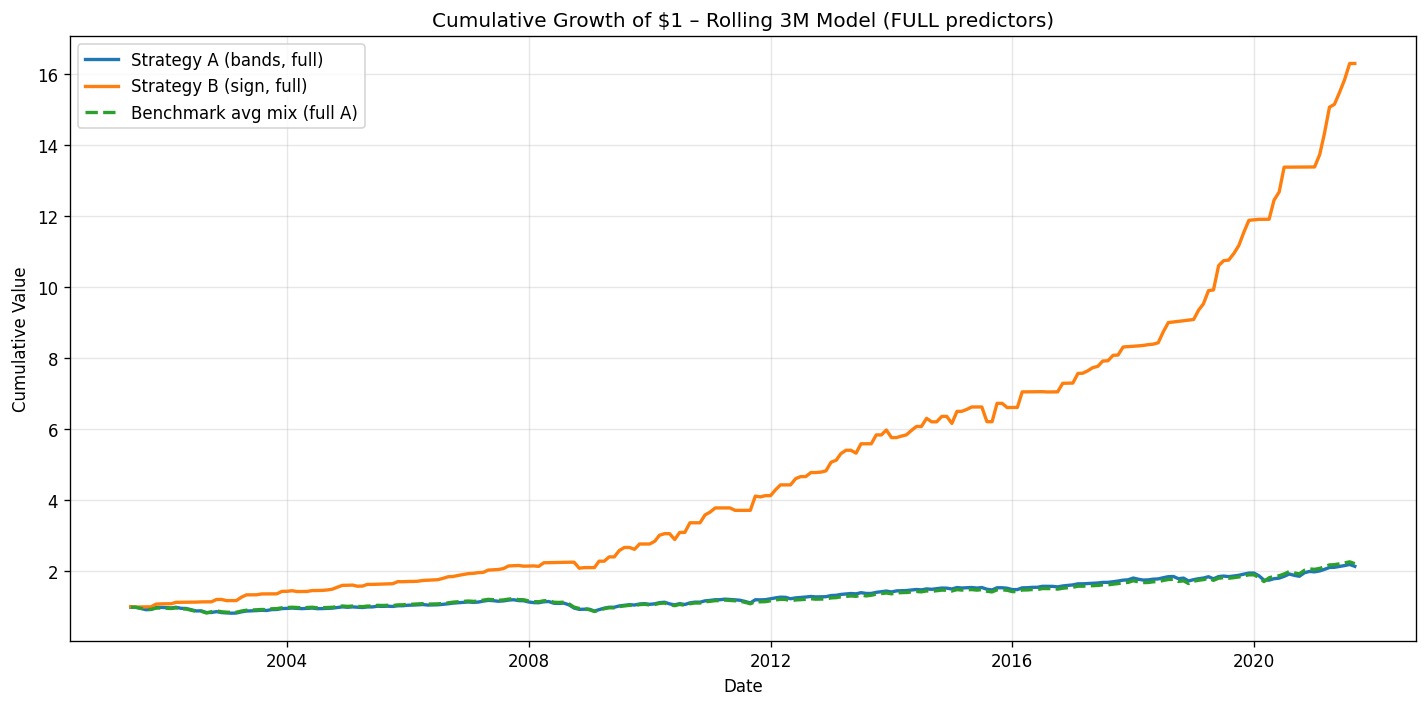

In [18]:
# ===============================
# CUMULATIVE WEALTH – FULL MODEL
# ===============================

idx_dt = ret_A_full.index.to_timestamp()

cum_A_full        = np.exp(ret_A_full.cumsum())
cum_B_full        = np.exp(ret_B_full.cumsum())
cum_bench_100     = np.exp(ret_bench_100.cumsum())
cum_bench_avg_full= np.exp(ret_bench_avg_full.cumsum())

plt.figure(figsize=(12,6))
plt.plot(idx_dt, cum_A_full,        label="Strategy A (bands, full)", linewidth=2)
plt.plot(idx_dt, cum_B_full,        label="Strategy B (sign, full)", linewidth=2)
# plt.plot(idx_dt, cum_bench_100,     label="Benchmark 100% S&P", linewidth=2, color="green")
plt.plot(idx_dt, cum_bench_avg_full,label="Benchmark avg mix (full A)", linewidth=2, linestyle="--")

plt.title("Cumulative Growth of $1 – Rolling 3M Model (FULL predictors)")
plt.xlabel("Date")
plt.ylabel("Cumulative Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

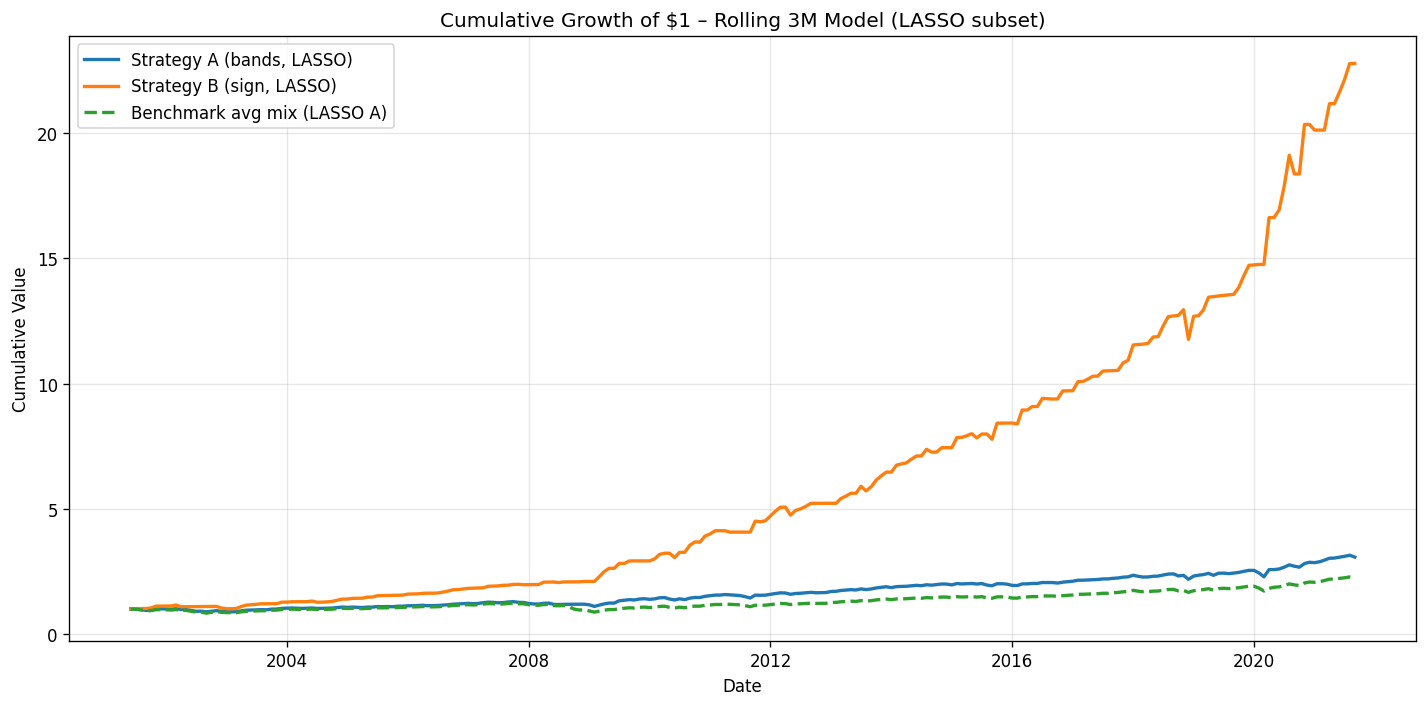

In [17]:
# ===============================
# CUMULATIVE WEALTH – LASSO MODEL
# ===============================

cum_A_L        = np.exp(ret_A_L.cumsum())
cum_B_L        = np.exp(ret_B_L.cumsum())
cum_bench_avg_L= np.exp(ret_bench_avg_L.cumsum())

plt.figure(figsize=(12,6))
plt.plot(idx_dt, cum_A_L,        label="Strategy A (bands, LASSO)", linewidth=2)
plt.plot(idx_dt, cum_B_L,        label="Strategy B (sign, LASSO)", linewidth=2)
# plt.plot(idx_dt, cum_bench_100,  label="Benchmark 100% S&P", linewidth=2, color="green")
plt.plot(idx_dt, cum_bench_avg_L,label="Benchmark avg mix (LASSO A)", linewidth=2, linestyle="--")

plt.title("Cumulative Growth of $1 – Rolling 3M Model (LASSO subset)")
plt.xlabel("Date")
plt.ylabel("Cumulative Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()